### Imports

In [1]:
# Import des outils de tables
import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

# Import des outils de machine learning
from sklearn.model_selection import GridSearchCV, train_test_split

# Import des modèles
from xgboost import XGBClassifier
from tabicl import TabICLClassifier # https://github.com/soda-inria/tabicl
from sklearn.ensemble import RandomForestClassifier


# Import des métriques d'évaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Options d'affichage 
from IPython.display import clear_output, display

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Téléchargement du dataset

In [2]:
df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "heptapod/titanic",
    "train_and_test2.csv"
)

df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


### Séparation en train, test

In [3]:
# Variables explicatives
X = df.iloc[:,:-1]

# Variable à prédire
y = df.iloc[:, -1] # df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1047, 27)
(262, 27)
(1047,)
(262,)


### Sous-échantillonnage des catégories

In [4]:
# Reconstruction temporaire du train
target = df.columns[-1]
train = X_train.copy()
train[target] = y_train

# Taille de la classe minoritaire dans le train
n_min = train[target].value_counts().min()

# Sous-échantillonnage de chaque classe
train_equilibre = (
    train.groupby(target, group_keys=False)
         .sample(n=n_min, random_state=42)
         .sample(frac=1, random_state=42)
)

# Séparation X/y du train équilibré
X_train = train_equilibre.drop(columns=target)
y_train = train_equilibre[target]

### Introduction de valeurs manquantes

In [5]:
def ajouter_nan(df, proportion=0.10, colonnes=None, seed=42):
    resultat = df.copy()

    if colonnes is None:
        colonnes = resultat.columns.tolist()

    sous_df = resultat[colonnes]
    cellules_valides = np.argwhere(sous_df.notna().to_numpy())

    rng = np.random.default_rng(seed)
    nombre = round(proportion * len(cellules_valides))

    cellules_choisies = rng.choice(
        len(cellules_valides),
        size=nombre,
        replace=False
    )

    masque = np.zeros(sous_df.shape, dtype=bool)
    lignes, cols = cellules_valides[cellules_choisies].T
    masque[lignes, cols] = True

    resultat[colonnes] = sous_df.mask(masque)

    # Utile pour savoir quelles valeurs ont été artificiellement supprimées
    masque = pd.DataFrame(
        masque,
        index=df.index,
        columns=colonnes
    )

    return resultat, masque

### Préparation du tableau des Scores

In [6]:
modeles = ["TFM (TabICL)", "Random Forest", "XGBoost"]
metriques = ["Accuracy", "Precision", "Recall", "F1-score"]
proportions_nan = np.linspace(0.0, 0.99, 100)

colonnes_resultats = pd.MultiIndex.from_product(
    [modeles, metriques],
    names=["Modèle", "Métrique"]
)

resultats = pd.DataFrame(
    index=proportions_nan,
    columns=colonnes_resultats,
    dtype=float
)
resultats.index.name = "Proportion de NaN"

param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1]
}

meilleurs_parametres_xgb = pd.DataFrame(
    index=proportions_nan,
    columns=param_grid.keys()
)
meilleurs_parametres_xgb.index.name = "Proportion de NaN"

### Prédictions & Évaluation des résultats

In [7]:
def calculer_metriques(y_reel, y_prediction):
    return [
        accuracy_score(y_reel, y_prediction),
        precision_score(y_reel, y_prediction, zero_division=0),
        recall_score(y_reel, y_prediction, zero_division=0),
        f1_score(y_reel, y_prediction, zero_division=0)
    ]


for proportion in resultats.index:

    # Même jeu d'entraînement dégradé pour les trois modèles
    X_train_emmental, _ = ajouter_nan(X_train, proportion)

    # Tabular Foundation Model
    model_tfm = TabICLClassifier(kv_cache=True)
    model_tfm.fit(X_train_emmental, y_train)
    y_pred_tfm = model_tfm.predict(X_test)

    # Random Forest
    model_rf = RandomForestClassifier(random_state=42)
    model_rf.fit(X_train_emmental, y_train)
    y_pred_rf = model_rf.predict(X_test)

    # XGBoost

    grid_xgb = GridSearchCV(
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),
        param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    grid_xgb.fit(X_train_emmental, y_train)
    y_pred_xgb = grid_xgb.predict(X_test)


    # Stockage des scores et des meilleurs paramètres XGBoost
    resultats.loc[proportion, ("TFM (TabICL)", slice(None))] = calculer_metriques(
        y_test, y_pred_tfm
    )
    resultats.loc[proportion, ("Random Forest", slice(None))] = calculer_metriques(
        y_test, y_pred_rf
    )

    resultats.loc[proportion, ("XGBoost", slice(None))] = calculer_metriques(
        y_test, y_pred_xgb
    )
    meilleurs_parametres_xgb.loc[proportion] = [
        grid_xgb.best_params_[parametre]
        for parametre in meilleurs_parametres_xgb.columns
    ]

    clear_output(wait=True)
    print(f"Proportion de NaN traitée : {proportion:.0%}")
    display(
        resultats.loc[proportion]
                 .unstack(level="Métrique")
                 .loc[modeles, metriques]
    )

Proportion de NaN traitée : 99%


Métrique,Accuracy,Precision,Recall,F1-score
Modèle,,,,
TFM (TabICL),0.660305,0.309091,0.250000,0.276423
Random Forest,0.583969,0.358621,0.764706,0.488263
XGBoost,0.641221,0.283333,0.250000,0.265625


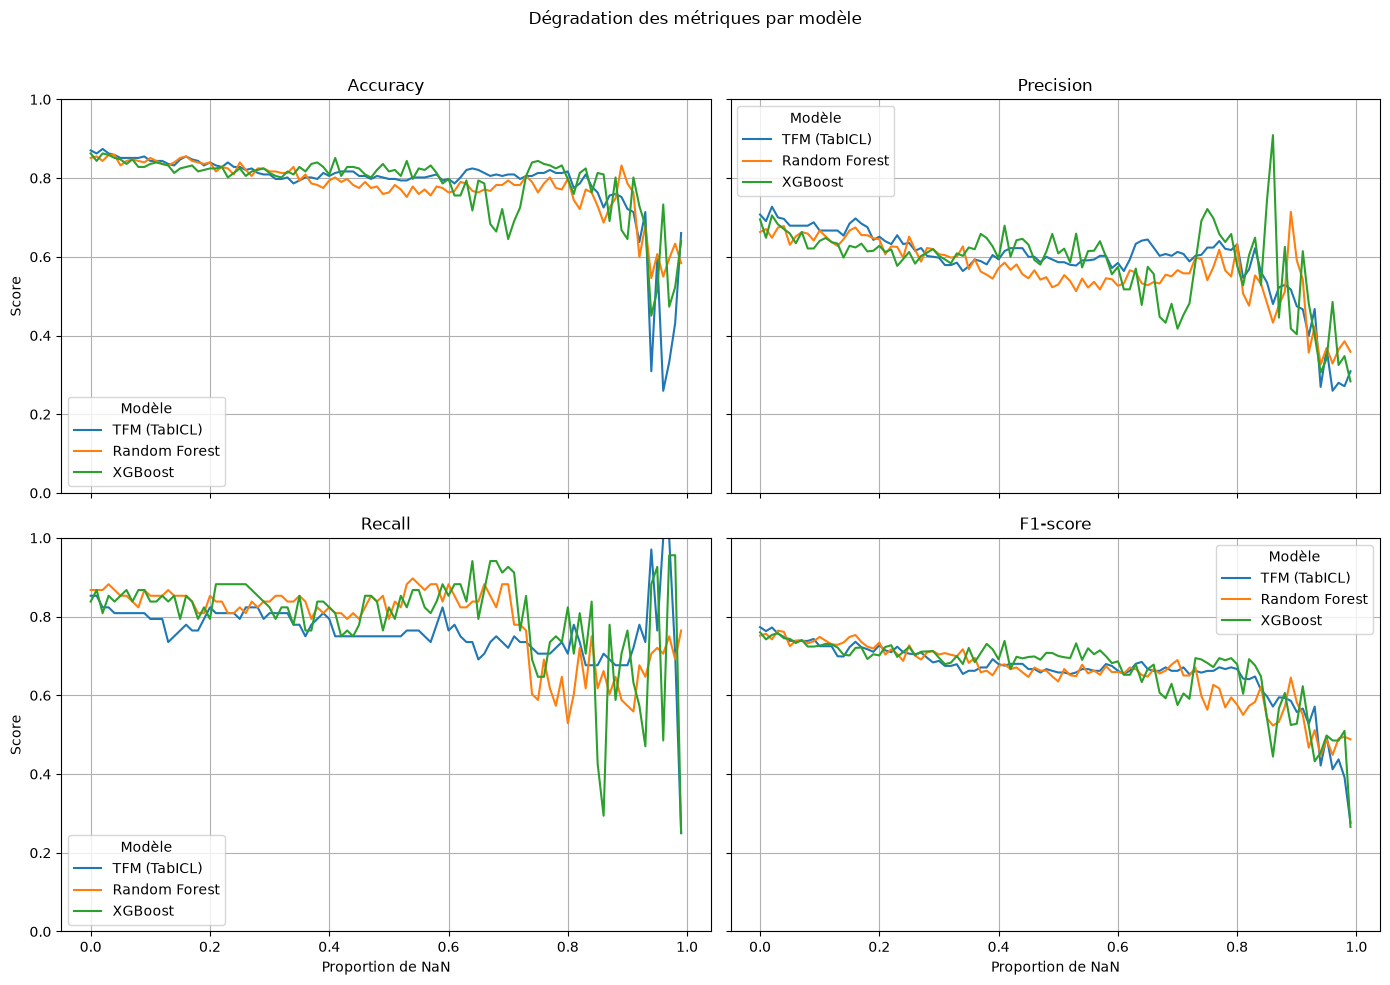

In [8]:
resultats_float = resultats.astype(float)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

for axe, metrique in zip(axes.flat, metriques):
    resultats_float.xs(
        metrique, axis=1, level="Métrique"
    ).plot(ax=axe)
    axe.set_title(metrique)
    axe.set_xlabel("Proportion de NaN")
    axe.set_ylabel("Score")
    axe.set_ylim(0, 1)
    axe.grid(True)

fig.suptitle("Dégradation des métriques par modèle")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

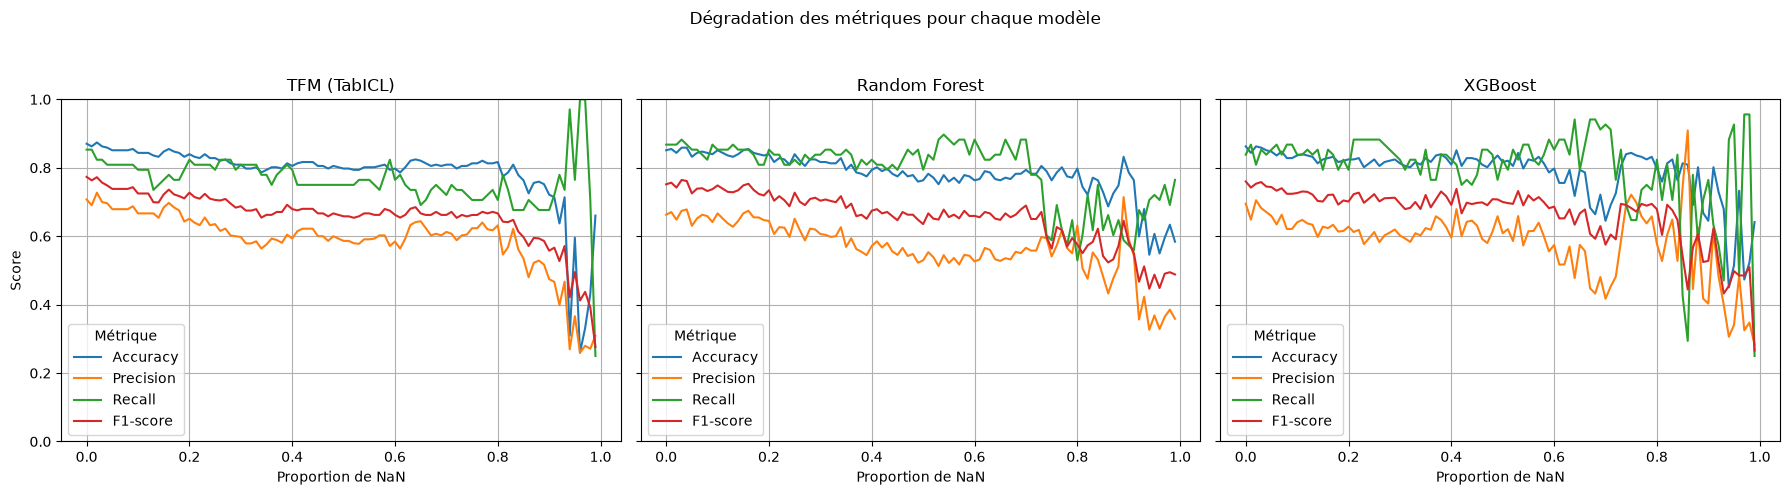

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for axe, modele in zip(axes, modeles):
    resultats_float[modele].plot(ax=axe)
    axe.set_title(modele)
    axe.set_xlabel("Proportion de NaN")
    axe.set_ylabel("Score")
    axe.set_ylim(0, 1)
    axe.grid(True)

fig.suptitle("Dégradation des métriques pour chaque modèle")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()